# Car Pricing Anaylsis

## Part 1: Problem Definition & EDA

### Background Information

1. **Problem**:
This project aims to analyze factors that influence car pricing, particularly focusing on exploring and modeling the `MSRP` (Manufacturer’s Suggested Retail Price) based on various vehicle features.

2. **Stakeholders**:
This is a data challenge propsed by a potentail employer to how well I work with data and regression models. Ideally car manufactors, dealerships, and potential car buyers may be intereseted how different features impact car prices.

3. **Data Overview**:
The dataset includes information on vehicle specifications and attributes that may correlate with pricing, such as engine power, fuel type, transmission type, and vehicle size.


  


In [1]:
# Code to load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
# import data set from googlecolab files
from google.colab import files

# Open file dialog to upload CSV file
uploaded = files.upload()

Saving car_pricing.csv to car_pricing (3).csv


In [2]:
# Load data
df = pd.read_csv(list(uploaded.keys())[0])

# Display the first few rows of the DataFrame
print("First few rows of the DataFrame:\n", df.head())

# Display summary statistics
print("\nSummary Statistics:\n", df.describe())

# Display the DataFrame's information
print("\nDataFrame Info:\n", df.info())

print(df.shape)

# summarize the data
df.describe()

First few rows of the DataFrame:
   Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [25]:
df_plot = df[['Engine HP','MSRP']]
print(df_plot.head(9))

df_plot2 = df[['city mpg','MSRP']]
print(df_plot2.head(9))

df_plot3 = df[['highway MPG','MSRP']]
print(df_plot3.head(9))

   Engine HP   MSRP
0      335.0  46135
1      300.0  40650
2      300.0  36350
3      230.0  29450
4      230.0  34500
5      230.0  31200
6      300.0  44100
7      300.0  39300
8      230.0  36900
   city mpg   MSRP
0        19  46135
1        19  40650
2        20  36350
3        18  29450
4        18  34500
5        18  31200
6        17  44100
7        20  39300
8        18  36900
   highway MPG   MSRP
0           26  46135
1           28  40650
2           28  36350
3           28  29450
4           28  34500
5           28  31200
6           26  44100
7           28  39300
8           28  36900


Exploring feature relationships between independant variables and target variable MSRP

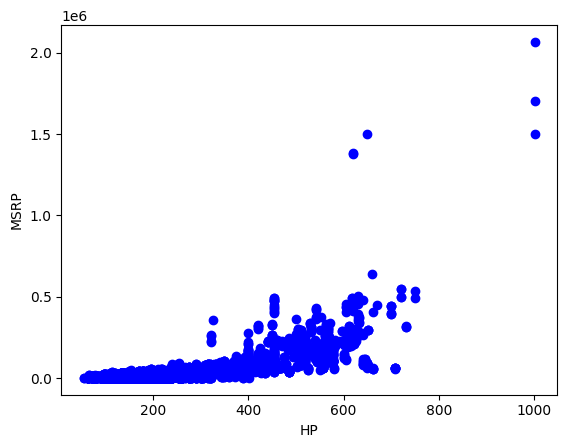

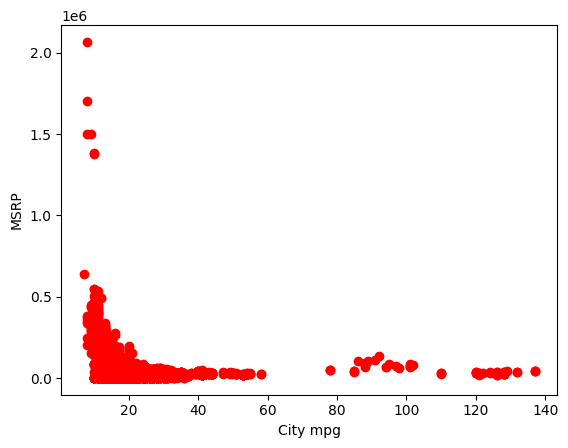

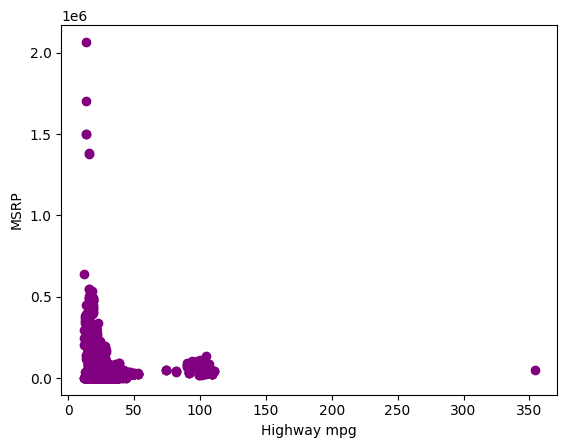

In [26]:
plt.scatter(df_plot['Engine HP'], df_plot['MSRP'],  color='blue')
plt.xlabel("HP")
plt.ylabel("MSRP")
plt.show()

plt.scatter(df_plot2['city mpg'], df_plot2['MSRP'],  color='red')
plt.xlabel("City mpg")
plt.ylabel("MSRP")
plt.show()

plt.scatter(df_plot3['highway MPG'], df_plot2['MSRP'],  color='purple')
plt.xlabel("Highway mpg")
plt.ylabel("MSRP")
plt.show()

### EDA

#### 1. Conversion of Categorical Variables
- **Driven_Wheels:** Use OneHotEncoder to convert this categorical variable into numerical format.
- **Vehicle Size:** Use OrdinalEncoder to convert this categorical variable.
- After encoding, drop the original categorical variables.

In [5]:
car_data = df.copy()

# Convert categorical variables
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# One-hot encode 'Driven_Wheels'
car_data = pd.concat([car_data, pd.get_dummies(car_data['Driven_Wheels'], prefix='Driven_Wheels')], axis=1)
car_data.drop('Driven_Wheels', axis=1, inplace=True)

# Ordinal encode 'Vehicle Size'
ordinal_encoder = OrdinalEncoder(categories=[['Compact', 'Midsize', 'Large']])
car_data['Vehicle_Size'] = ordinal_encoder.fit_transform(car_data[['Vehicle Size']])
car_data.drop('Vehicle Size', axis=1, inplace=True)

# Drop other unused categorical variables
car_data.drop(['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Market Category', 'Vehicle Style'], axis=1, inplace=True)

car_data.head()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Driven_Wheels_all wheel drive,Driven_Wheels_four wheel drive,Driven_Wheels_front wheel drive,Driven_Wheels_rear wheel drive,Vehicle_Size
0,2011,335.0,6.0,2.0,26,19,3916,46135,False,False,False,True,0.0
1,2011,300.0,6.0,2.0,28,19,3916,40650,False,False,False,True,0.0
2,2011,300.0,6.0,2.0,28,20,3916,36350,False,False,False,True,0.0
3,2011,230.0,6.0,2.0,28,18,3916,29450,False,False,False,True,0.0
4,2011,230.0,6.0,2.0,28,18,3916,34500,False,False,False,True,0.0


#### Data Cleaning
Examine and handle missing values, and remove duplicates if present.

In [6]:
# Handle missing values by removing rows with null values
car_data.dropna(inplace=True)

# Remove duplicates if any
car_data.drop_duplicates(inplace=True)

car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10922 entries, 0 to 11913
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             10922 non-null  int64  
 1   Engine HP                        10922 non-null  float64
 2   Engine Cylinders                 10922 non-null  float64
 3   Number of Doors                  10922 non-null  float64
 4   highway MPG                      10922 non-null  int64  
 5   city mpg                         10922 non-null  int64  
 6   Popularity                       10922 non-null  int64  
 7   MSRP                             10922 non-null  int64  
 8   Driven_Wheels_all wheel drive    10922 non-null  bool   
 9   Driven_Wheels_four wheel drive   10922 non-null  bool   
 10  Driven_Wheels_front wheel drive  10922 non-null  bool   
 11  Driven_Wheels_rear wheel drive   10922 non-null  bool   
 12  Vehicle_Size           

#### Data Visualization
Use histograms, correlation plots, and other visualizations to explore data distribution and relationships.

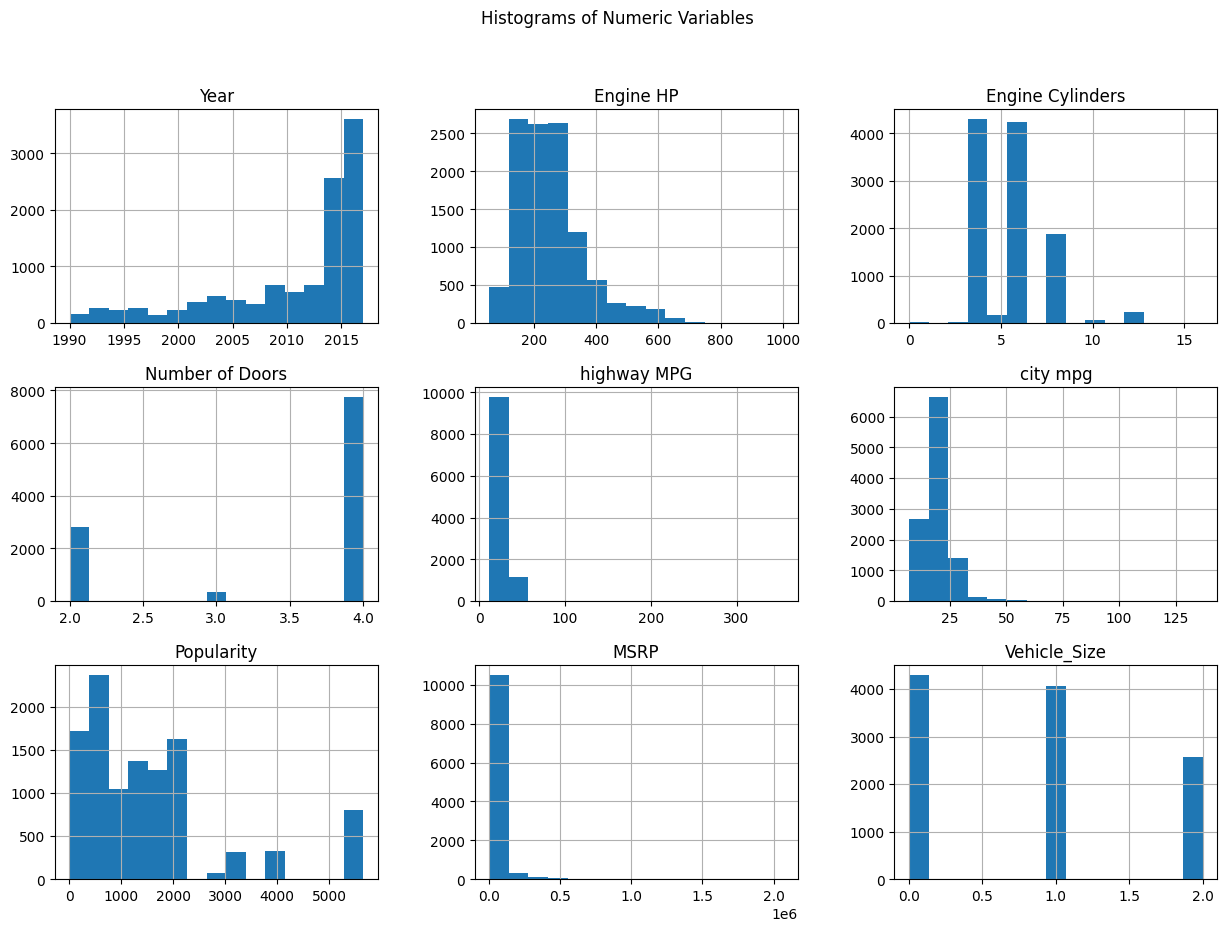

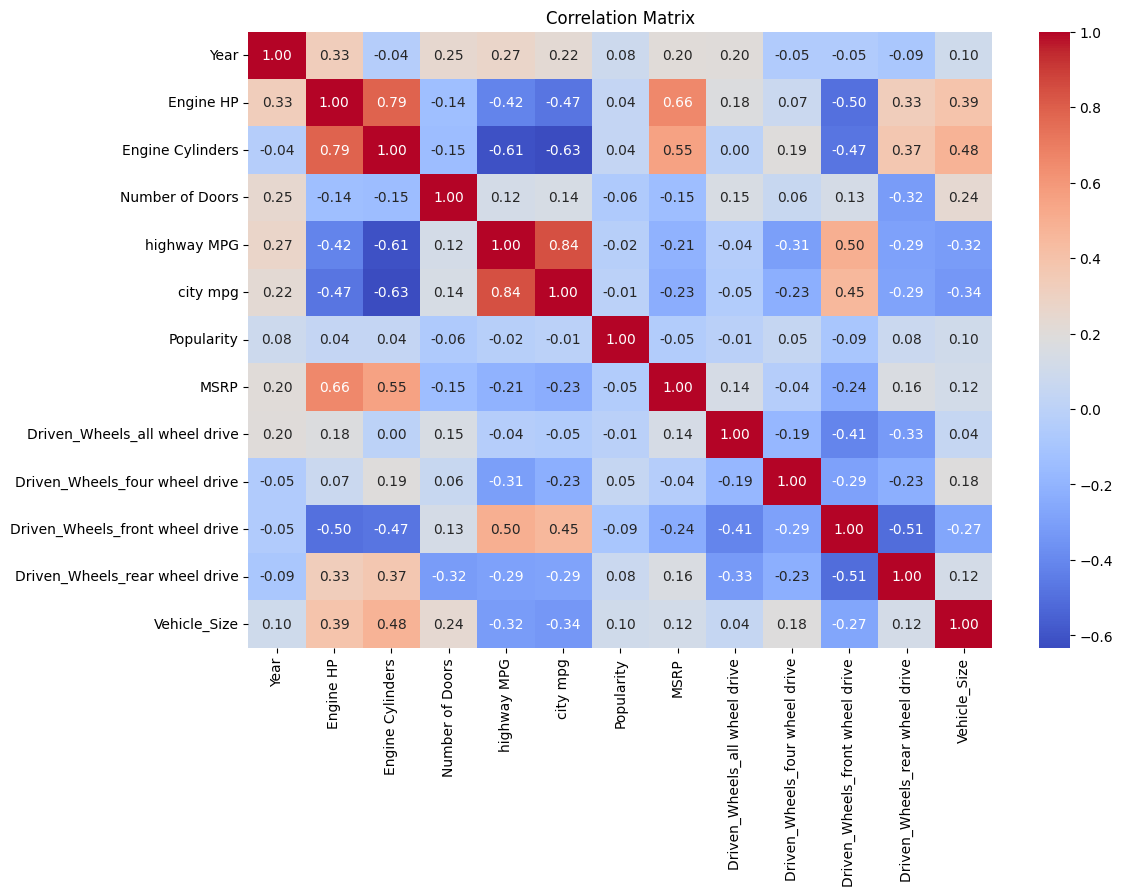

In [7]:
# Histograms
car_data.hist(bins=15, figsize=(15, 10))
plt.suptitle("Histograms of Numeric Variables")
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(car_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [8]:
# Train-test split
X = car_data.drop('MSRP', axis=1)  # All features except the target (MSRP)
y = car_data['MSRP']               # Target variable

# Split data into training and test sets with 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Part 2: Simple Regression Models

Train three simple regression models with a single feature.
1. Simple regression with Engine HP
2. Simple Regression with highway mpg
3. linear-Log regression with Engine HP

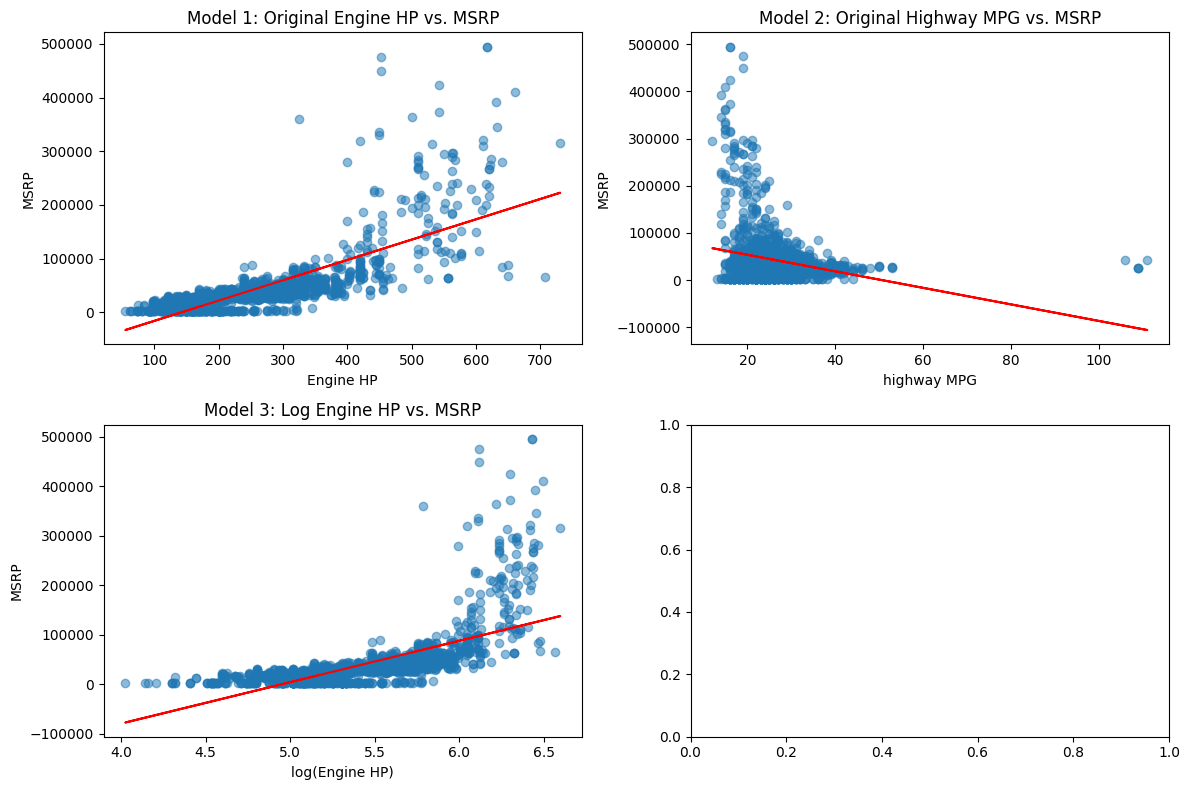

             Scenario  Coefficient      Intercept           MSE        R2
0    Engine HP & MSRP   378.275672  -53741.964771  1.141173e+09  0.536765
1  highway MPG & MSRP -1752.678729   88691.601470  2.323778e+09  0.056712
2       Log Engine HP -1752.678729 -413509.435786  1.489962e+09  0.395182


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to evaluate model
def evaluate_model(model, X, y):
    predictions = model.predict(X)
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    r2 = r2_score(y, predictions)
    return mae, mse, r2

# Model 1: Single feature regression with Engine HP
lr1 = LinearRegression()
lr1.fit(X_train[['Engine HP']], y_train)
mae1, mse1, r21 = evaluate_model(lr1, X_test[['Engine HP']], y_test)

# Model 2: Single feature regression with highway MPG
lr2 = LinearRegression()
lr2.fit(X_train[['highway MPG']], y_train)
mae2, mse2, r22 = evaluate_model(lr2, X_test[['highway MPG']], y_test)

# Model 3: Log-linear response with Engine HP
X2_train = X_train[['Engine HP']].copy()
X2_test = X_test[['Engine HP']].copy()
X2_train['Engine HP'] = np.log(X2_train['Engine HP'] + 1)  # Avoid log(0)
X2_test['Engine HP'] = np.log(X2_test['Engine HP'] + 1)

lr3 = LinearRegression()
lr3.fit(X2_train, y_train)
mae3, mse3, r23 = evaluate_model(lr3, X2_test, y_test)

# Summarize coefficients, intercepts, MSE, and R2 values
coef_intercepts_mse_r2 = {
    'Scenario': ['Engine HP & MSRP', 'highway MPG & MSRP', 'Log Engine HP'],
    'Coefficient': [lr1.coef_[0], lr2.coef_[0], lr2.coef_[0]],
    'Intercept': [lr1.intercept_, lr2.intercept_, lr3.intercept_],
    'MSE': [mse1, mse2, mse3],
    'R2': [r21, r22, r23]
}

# Create a figure and subplots with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Model 1 plot
axes[0, 0].scatter(X_test[['Engine HP']], y_test, alpha=0.5)
axes[0, 0].plot(X_test[['Engine HP']], lr1.predict(X_test[['Engine HP']]), color='red')
axes[0, 0].set_title('Model 1: Original Engine HP vs. MSRP')
axes[0, 0].set_xlabel('Engine HP')
axes[0, 0].set_ylabel('MSRP')

# Model 2 plot
axes[0, 1].scatter(X_test[['highway MPG']], y_test, alpha=0.5)
axes[0, 1].plot(X_test[['highway MPG']], lr2.predict(X_test[['highway MPG']]), color='red')
axes[0, 1].set_title('Model 2: Original Highway MPG vs. MSRP')
axes[0, 1].set_xlabel('highway MPG')
axes[0, 1].set_ylabel('MSRP')

# Model 3 plot Log form of Engine HP, original form of MSRP
axes[1, 0].scatter(X2_test['Engine HP'], y_test, alpha=0.5)
axes[1, 0].plot(X2_test['Engine HP'], lr3.predict(X2_test), color='red')
axes[1, 0].set_title('Model 3: Log Engine HP vs. MSRP')
axes[1, 0].set_xlabel('log(Engine HP)')
axes[1, 0].set_ylabel('MSRP')

# Display the plot
plt.tight_layout()
plt.show()

# Create a DataFrame for the results
coef_df_sample = pd.DataFrame(coef_intercepts_mse_r2)
print(coef_df_sample)


### 2.1 Forward Selection

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Forward variable selection function
def forward_selection(X_train, X_test, y_train, y_test):
    initial_features = []  # Start with no features
    remaining_features = list(X_train.columns)  # All features that haven't been selected
    best_features = []
    best_mae, best_mse, best_r2 = np.inf, np.inf, -np.inf

    # Initialize variables to store best model performance
    final_mae, final_mse, final_r2 = None, None, None

    while remaining_features:
        mae_list, mse_list, r2_list = [], [], []
        model_list = []

        for feature in remaining_features:
            # Try the current feature along with the already selected features
            features_to_try = initial_features + [feature]

            # Train the model on the selected features
            model = LinearRegression()
            model.fit(X_train[features_to_try], y_train)

            # Make predictions
            y_pred = model.predict(X_test[features_to_try])

            # Evaluate performance
            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            mae_list.append((feature, mae))
            mse_list.append((feature, mse))
            r2_list.append((feature, r2))
            model_list.append((model, features_to_try))  # Store model and corresponding features

        # Find the best feature to add based on R² score (or any metric you prefer)
        best_feature_r2 = max(r2_list, key=lambda x: x[1])  # Highest R²
        best_feature_mae = min(mae_list, key=lambda x: x[1])  # Lowest MAE
        best_feature_mse = min(mse_list, key=lambda x: x[1])  # Lowest MSE

        # Add the best feature to the model
        best_features.append(best_feature_r2[0])
        initial_features.append(best_feature_r2[0])
        remaining_features.remove(best_feature_r2[0])

        # Update the best performance
        best_mae, best_mse, best_r2 = best_feature_mae[1], best_feature_mse[1], best_feature_r2[1]

        # Retrieve the model with the best R² and corresponding features
        best_model, best_features_to_try = model_list[r2_list.index(best_feature_r2)]

        # Print the model's coefficients for the selected features
        coef = best_model.coef_
        intercept = best_model.intercept_
        coef_list = zip(best_features_to_try, coef)

        print(f"Added Feature: {best_feature_r2[0]}")
        print(f"Current Model Features: {best_features_to_try}")
        print(f"Current Coefficients: {[f'{feature}: {coef_value:.4f}' for feature, coef_value in coef_list]}")
        print(f"Intercept: {intercept:.4f}")
        print(f"Current MAE: {best_mae:.2f}, MSE: {best_mse:.2f}, R²: {best_r2:.2f}")
        print("-" * 50)

        # Store the final best evaluation
        final_mae, final_mse, final_r2 = best_mae, best_mse, best_r2

    print("\nFinal Model Features:", best_features)
    print(f"Final MAE: {final_mae:.2f}, MSE: {final_mse:.2f}, R²: {final_r2:.2f}")

# Choose features that we would like to explore
X = car_data.drop(columns=['MSRP'])  # X contains all columns except 'MSRP'
y = car_data['MSRP']  # The dependent variable 'MSRP'

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Now you can run the forward selection with this data
forward_selection(X_train, X_test, y_train, y_test)

Added Feature: Engine HP
Current Model Features: ['Engine HP']
Current Coefficients: ['Engine HP: 369.6401']
Intercept: -51665.9391
Current MAE: 21678.60, MSE: 2515228363.83, R²: 0.41
--------------------------------------------------
Added Feature: Vehicle_Size
Current Model Features: ['Engine HP', 'Vehicle_Size']
Current Coefficients: ['Engine HP: 405.3921', 'Vehicle_Size: -13088.6589']
Intercept: -49785.3656
Current MAE: 19961.85, MSE: 2412895725.21, R²: 0.43
--------------------------------------------------
Added Feature: Engine Cylinders
Current Model Features: ['Engine HP', 'Vehicle_Size', 'Engine Cylinders']
Current Coefficients: ['Engine HP: 332.2123', 'Vehicle_Size: -15957.8616', 'Engine Cylinders: 6397.1210']
Intercept: -65229.8638
Current MAE: 19478.69, MSE: 2368150902.06, R²: 0.44
--------------------------------------------------
Added Feature: city mpg
Current Model Features: ['Engine HP', 'Vehicle_Size', 'Engine Cylinders', 'city mpg']
Current Coefficients: ['Engine HP:

### 2.2 Backward Selection

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Backward variable selection function
def backward_selection(X_train, X_test, y_train, y_test):
    # Ensure X_train and X_test are DataFrames
    X_train = pd.DataFrame(X_train)
    X_test = pd.DataFrame(X_test)

    # Start with all features in the model
    best_features = list(X_train.columns)

    while len(best_features) > 1:  # Ensure at least one feature remains
        # Train the model with the current set of features
        model = LinearRegression()
        model.fit(X_train[best_features], y_train)  # Fit model using current best features

        # Make predictions
        y_pred = model.predict(X_test[best_features])  # Predict using the same features

        # Calculate evaluation metrics
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Print results for the current set of features
        print(f"Remaining Features: {best_features}")
        print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")
        print("-" * 50)

        # Try removing one feature at a time and find the one that decreases R² the least
        worst_r2 = float('inf')
        feature_to_remove = None

        for feature in best_features:
            features_to_try = [f for f in best_features if f != feature]
            # Train the model without the current feature
            model.fit(X_train[features_to_try], y_train)
            y_pred_try = model.predict(X_test[features_to_try])
            r2_try = r2_score(y_test, y_pred_try)

            # Find the feature whose removal leads to the least decrease in R²
            if r2_try < worst_r2:
                worst_r2 = r2_try
                feature_to_remove = feature

        # Remove the feature that results in the least reduction in performance
        if feature_to_remove:
            best_features.remove(feature_to_remove)
            print(f"Removed Feature: {feature_to_remove}")
            print("-" * 50)

    # If only one feature remains, print the final evaluation
    if len(best_features) == 1:
        print(f"Final Remaining Feature: {best_features}")
        model.fit(X_train[best_features], y_train)
        y_pred = model.predict(X_test[best_features])
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Final Model with One Feature: {best_features}")
        print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")
        print("-" * 50)

# Example usage: Perform backward selection
# Ensure that X_train, X_test, y_train, and y_test are already defined, similar to forward selection.

backward_selection(X_train, X_test, y_train, y_test)


Remaining Features: ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'Driven_Wheels_all wheel drive', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive', 'Vehicle_Size']
MAE: 19941.42, MSE: 2242923034.49, R²: 0.47
--------------------------------------------------
Removed Feature: Engine HP
--------------------------------------------------
Remaining Features: ['Year', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'Driven_Wheels_all wheel drive', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive', 'Vehicle_Size']
MAE: 22709.17, MSE: 2533749004.06, R²: 0.40
--------------------------------------------------
Removed Feature: Engine Cylinders
--------------------------------------------------
Remaining Features: ['Year', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'Driven_Wheels_all whee

## Part 3: Conclusion
* Trained the linear model on entire data set
* Evaluted the perfomance

## Conclusion

The final model using 'Engine HP' as the single explanatory variable for MSRP yielded the following performance metrics:
- **Mean Absolute Error (MAE)**: 20819.47
- **Mean Squared Error (MSE)**: 1141173460.58
- **R^2 Score**: 0.54

Although this simple model provides some insight into the relationship between Engine HP and MSRP, a single-feature regression may not capture all the complexities affecting car pricing. I am not fully satisfied with the model's performance due to it's low R^2 value of 0.54, this indicates that only 54% of the variance in MSRP is explained by Engine HP. There's room for significant improvement. The MAE of 20819.47 which is relatively high, meaning the model's predictions could be off by that much on average.

### Next Steps
1. **Feature Expansion**: Incorporating additional features  (i.e., vehicle size, Engine Cylinders) could improve model performance based on the forward selection, leading to enhance predictive power.
2. **Advanced Models**: Trying more advanced models such as polynomial regression, Random Forest, or Gradient Boosting, would capture more complex relationships within the data and lead to better predictions.
3. **Data Exploration**: Deeper data exploration could uncover hidden patterns or interactions between features. Feature engineering, such as creating new features based on existing ones (e.g., combining 'Engine HP' and 'Engine Cylinders'), could also provide valuable insights.

### What I Would Do Differently ###

1. Start with Feature Selection: Implement forward or backward selection earlier in the process to identify the most relevant features and focus on those for model building.
2. Explore More Models: Experiment with a wider variety of regression models beyond simple linear regression to see which one performs best for this dataset.
3. Consider Interactions: Include interaction terms between features to capture potential synergistic effects that might influence MSRP.

Based on my findings, Engine HP is a significant factor in predicting car pricing, but that alone is not accurately sufficient to predict MSRP. Vehicle size, engine cylinders, and other unique feature could also influence car pricing. By incorporating these additional features in more advanced models may lead to a more comprehensive view of price modeling.

